
# Week 9: Urban Digital Twin Integration

## Overview
This notebook shows how **GeoAI flood intelligence** can be integrated into an **urban digital twin workflow**. In previous weeks, the focus was on building, evaluating, and operationalizing the flood analysis pipeline. This week connects those outputs to a broader city-scale representation.

An urban digital twin is not just a 3D model or map. It is a structured environment that can combine:
- geospatial context
- sensor or imagery-derived observations
- infrastructure layers
- temporal updates
- decision-support logic

In this notebook, students will build a simplified digital twin style workflow by linking flood predictions to spatial coordinates, infrastructure context, and operational status summaries.

## Learning Objectives
- Understand the role of digital twins in urban disaster management
- Link AI-derived flood outputs to geospatial location data
- Create a simple map-style representation of urban flood intelligence
- Interpret how spatial, temporal, and operational layers work together
- Understand how digital twin workflows support monitoring and decision-making

## Expected Outcome
By the end of this notebook, you should be able to explain how flood intelligence outputs can be embedded in a simplified urban digital twin framework for monitoring and decision support.



## Notebook Structure

1. Environment setup  
2. Why urban digital twin integration matters  
3. Example geospatial flood records  
4. Add digital twin context layers  
5. Spatial visualization  
6. Temporal update example  
7. Operational layer summary  
8. Infrastructure-aware interpretation  
9. Mini exercise  
10. Weekly assignment  

> This notebook uses a simplified coordinate-based representation so students can understand the digital twin logic without requiring a full GIS or 3D platform.


In [1]:

# Week 9 setup: imports and environment check

import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Python version:", sys.version.split()[0])
print("Working directory:", os.getcwd())


Python version: 3.12.12
Working directory: /content


In [2]:

# Create output folder for this week

BASE_DIR = Path.cwd()
OUTPUT_DIR = BASE_DIR / "outputs" / "week09"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Output directory ready:", OUTPUT_DIR)


Output directory ready: /content/outputs/week09



## Why Urban Digital Twin Integration Matters

A flood prediction becomes more useful when it is connected to the city context around it.

For example, a digital twin can help answer:
- Where is the flooded location relative to roads, intersections, and facilities?
- Which critical sites are near the affected area?
- How are conditions changing over time?
- Which layers should be monitored together?
- How can this information support coordinated response?

This means a digital twin workflow is often about **integration**, not only visualization.



## Example Geospatial Flood Records

The next table represents urban flood intelligence outputs that have already been georeferenced.  
Each record contains:
- a location ID
- x and y coordinates in a simplified city grid
- predicted flood level
- confidence
- passability status
- whether the point is near a critical facility


In [3]:

# Synthetic geospatial flood records

flood_geo_df = pd.DataFrame([
    {"location_id": "L1", "x": 1.2, "y": 7.8, "pred_level": 0, "confidence": 0.94, "passability": "Passable", "near_critical_site": False},
    {"location_id": "L2", "x": 2.5, "y": 6.9, "pred_level": 1, "confidence": 0.85, "passability": "Passable with caution", "near_critical_site": False},
    {"location_id": "L3", "x": 4.1, "y": 6.2, "pred_level": 2, "confidence": 0.81, "passability": "Restricted", "near_critical_site": True},
    {"location_id": "L4", "x": 5.8, "y": 5.6, "pred_level": 3, "confidence": 0.78, "passability": "Closed", "near_critical_site": True},
    {"location_id": "L5", "x": 7.2, "y": 5.0, "pred_level": 4, "confidence": 0.92, "passability": "Closed", "near_critical_site": False},
    {"location_id": "L6", "x": 3.2, "y": 3.9, "pred_level": 2, "confidence": 0.58, "passability": "Restricted", "near_critical_site": False},
    {"location_id": "L7", "x": 6.6, "y": 3.4, "pred_level": 1, "confidence": 0.67, "passability": "Passable with caution", "near_critical_site": True},
    {"location_id": "L8", "x": 8.1, "y": 2.8, "pred_level": 3, "confidence": 0.89, "passability": "Closed", "near_critical_site": False},
])

flood_geo_df


,location_id,x,y,pred_level,confidence,passability,near_critical_site
0,L1,1.2,7.8,0,0.94,Passable,False
1,L2,2.5,6.9,1,0.85,Passable with caution,False
2,L3,4.1,6.2,2,0.81,Restricted,True
3,L4,5.8,5.6,3,0.78,Closed,True
4,L5,7.2,5.0,4,0.92,Closed,False
5,L6,3.2,3.9,2,0.58,Restricted,False
6,L7,6.6,3.4,1,0.67,Passable with caution,True
7,L8,8.1,2.8,3,0.89,Closed,False



## Add Digital Twin Context Layers

A digital twin becomes more useful when the AI outputs are combined with infrastructure context.  
For this teaching example, we define two simple context layers:

- **Critical facilities** such as a hospital, emergency operations center, and substation
- **Road corridors** represented conceptually as major routes across the city grid

This is a simplified abstraction of how digital twin layers are organized.


In [4]:

# Synthetic critical facility layer

critical_sites_df = pd.DataFrame([
    {"site_name": "Hospital", "x": 5.5, "y": 5.9, "site_type": "Healthcare"},
    {"site_name": "EOC", "x": 4.0, "y": 6.7, "site_type": "Emergency Operations"},
    {"site_name": "Substation", "x": 6.8, "y": 3.2, "site_type": "Utility"},
])

critical_sites_df


,site_name,x,y,site_type
0,Hospital,5.5,5.9,Healthcare
1,EOC,4.0,6.7,Emergency Operations
2,Substation,6.8,3.2,Utility



## Visualize the Simplified Digital Twin Map

The next cell creates a simple map-style view using:
- flood prediction points
- critical sites
- a conceptual city grid
- labels showing location IDs

This is not a full GIS map, but it demonstrates the core idea of layering AI outputs into an urban context.


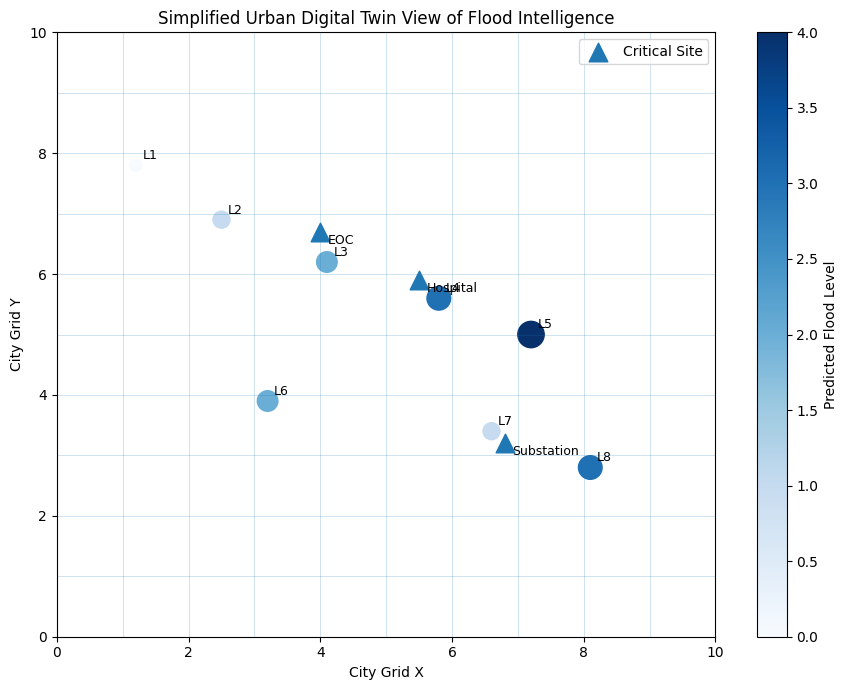

In [5]:

# Simple spatial visualization of flood intelligence in a digital twin style view

fig, ax = plt.subplots(figsize=(9, 7))

# Plot city grid
for gx in range(0, 11):
    ax.axvline(gx, linewidth=0.5, alpha=0.3)
for gy in range(0, 11):
    ax.axhline(gy, linewidth=0.5, alpha=0.3)

# Plot flood points with marker size related to severity
sizes = 80 + flood_geo_df["pred_level"] * 70
scatter = ax.scatter(
    flood_geo_df["x"],
    flood_geo_df["y"],
    s=sizes,
    c=flood_geo_df["pred_level"],
    cmap="Blues"
)

# Add labels
for _, row in flood_geo_df.iterrows():
    ax.text(row["x"] + 0.1, row["y"] + 0.1, row["location_id"], fontsize=9)

# Plot critical sites
ax.scatter(
    critical_sites_df["x"],
    critical_sites_df["y"],
    marker="^",
    s=180,
    label="Critical Site"
)

for _, row in critical_sites_df.iterrows():
    ax.text(row["x"] + 0.12, row["y"] - 0.2, row["site_name"], fontsize=9)

ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_title("Simplified Urban Digital Twin View of Flood Intelligence")
ax.set_xlabel("City Grid X")
ax.set_ylabel("City Grid Y")
ax.legend(loc="upper right")

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Predicted Flood Level")

plt.tight_layout()
plt.show()



### What This Represents
This figure shows how AI-derived flood outputs can be placed into a city context.  
A digital twin can use this structure to connect:
- severity
- location
- infrastructure proximity
- passability
- operational actions



## Add Proximity-Based Infrastructure Context

One useful digital twin function is identifying which flood locations are close to critical infrastructure.  
We calculate a simple Euclidean distance from each flood point to the nearest critical site.


In [6]:

# Compute nearest critical site distance

def nearest_site_info(x, y, sites_df):
    distances = np.sqrt((sites_df["x"] - x)**2 + (sites_df["y"] - y)**2)
    idx = distances.idxmin()
    return sites_df.loc[idx, "site_name"], float(distances.loc[idx])

nearest_site_names = []
nearest_site_distances = []

for _, row in flood_geo_df.iterrows():
    site_name, dist = nearest_site_info(row["x"], row["y"], critical_sites_df)
    nearest_site_names.append(site_name)
    nearest_site_distances.append(round(dist, 2))

flood_geo_df["nearest_site"] = nearest_site_names
flood_geo_df["distance_to_nearest_site"] = nearest_site_distances

flood_geo_df[["location_id", "pred_level", "nearest_site", "distance_to_nearest_site"]]


,location_id,pred_level,nearest_site,distance_to_nearest_site
0,L1,0,EOC,3.01
1,L2,1,EOC,1.51
2,L3,2,EOC,0.51
3,L4,3,Hospital,0.42
4,L5,4,Substation,1.84
5,L6,2,EOC,2.91
6,L7,1,Substation,0.28
7,L8,3,Substation,1.36



## Infrastructure-Aware Risk Interpretation

A Level 2 flood near a hospital access route may deserve more attention than a Level 2 flood in a low-priority area.  
This is where digital twin integration becomes valuable: it enables **context-aware interpretation** rather than relying only on the raw class label.


In [7]:

# Create a context-aware urgency flag

def context_urgency(row):
    if row["pred_level"] >= 4:
        return "Critical"
    if row["pred_level"] >= 3 and row["distance_to_nearest_site"] < 1.5:
        return "Critical"
    if row["pred_level"] >= 2 and row["distance_to_nearest_site"] < 1.2:
        return "High"
    if row["pred_level"] >= 2:
        return "Moderate"
    return "Routine"

flood_geo_df["context_urgency"] = flood_geo_df.apply(context_urgency, axis=1)
flood_geo_df[["location_id", "pred_level", "nearest_site", "distance_to_nearest_site", "context_urgency"]]


,location_id,pred_level,nearest_site,distance_to_nearest_site,context_urgency
0,L1,0,EOC,3.01,Routine
1,L2,1,EOC,1.51,Routine
2,L3,2,EOC,0.51,High
3,L4,3,Hospital,0.42,Critical
4,L5,4,Substation,1.84,Critical
5,L6,2,EOC,2.91,Moderate
6,L7,1,Substation,0.28,Routine
7,L8,3,Substation,1.36,Critical



## Add a Temporal Update Layer

Urban digital twins are dynamic. Conditions change over time.

To illustrate this, we create a simple temporal sequence showing how flood severity at selected locations changes over three timestamps:
- T1
- T2
- T3

This is a simplified representation of how streaming or repeated updates might appear in a real system.


In [8]:

# Synthetic temporal updates

temporal_df = pd.DataFrame([
    {"time": "T1", "location_id": "L3", "pred_level": 1},
    {"time": "T2", "location_id": "L3", "pred_level": 2},
    {"time": "T3", "location_id": "L3", "pred_level": 2},
    {"time": "T1", "location_id": "L4", "pred_level": 2},
    {"time": "T2", "location_id": "L4", "pred_level": 3},
    {"time": "T3", "location_id": "L4", "pred_level": 4},
    {"time": "T1", "location_id": "L7", "pred_level": 1},
    {"time": "T2", "location_id": "L7", "pred_level": 1},
    {"time": "T3", "location_id": "L7", "pred_level": 0},
])

temporal_df


,time,location_id,pred_level
0,T1,L3,1
1,T2,L3,2
2,T3,L3,2
3,T1,L4,2
4,T2,L4,3
5,T3,L4,4
6,T1,L7,1
7,T2,L7,1
8,T3,L7,0


In [9]:

# Pivot temporal data for easier reading

temporal_pivot = temporal_df.pivot(index="time", columns="location_id", values="pred_level")
temporal_pivot


location_id,L3,L4,L7
time,,,
T1,1,2,1
T2,2,3,1
T3,2,4,0


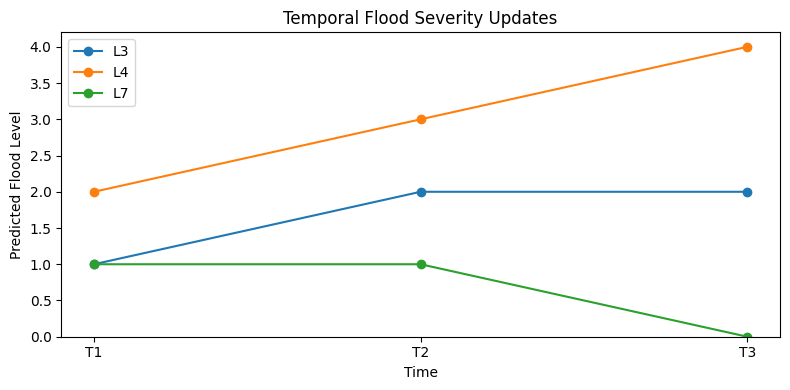

In [10]:

# Plot temporal changes for selected locations

fig, ax = plt.subplots(figsize=(8, 4))

for loc_id in temporal_df["location_id"].unique():
    subset = temporal_df[temporal_df["location_id"] == loc_id]
    ax.plot(subset["time"], subset["pred_level"], marker="o", label=loc_id)

ax.set_title("Temporal Flood Severity Updates")
ax.set_xlabel("Time")
ax.set_ylabel("Predicted Flood Level")
ax.set_ylim(0, 4.2)
ax.legend()
plt.tight_layout()
plt.show()



### Interpretation
Temporal updates allow the digital twin to show:
- worsening conditions
- stable conditions
- improving conditions
- locations that require repeated monitoring

This is important because disaster monitoring is rarely static.



## Build an Operational Digital Twin Summary Layer

The next table merges spatial and operational information into one compact view.


In [11]:

# Create a compact digital twin operational view

dt_summary = flood_geo_df[[
    "location_id",
    "x",
    "y",
    "pred_level",
    "confidence",
    "passability",
    "nearest_site",
    "distance_to_nearest_site",
    "context_urgency"
]].sort_values(["context_urgency", "pred_level"], ascending=[True, False])

dt_summary


,location_id,x,y,pred_level,confidence,passability,nearest_site,distance_to_nearest_site,context_urgency
4,L5,7.2,5.0,4,0.92,Closed,Substation,1.84,Critical
3,L4,5.8,5.6,3,0.78,Closed,Hospital,0.42,Critical
7,L8,8.1,2.8,3,0.89,Closed,Substation,1.36,Critical
2,L3,4.1,6.2,2,0.81,Restricted,EOC,0.51,High
5,L6,3.2,3.9,2,0.58,Restricted,EOC,2.91,Moderate
1,L2,2.5,6.9,1,0.85,Passable with caution,EOC,1.51,Routine
6,L7,6.6,3.4,1,0.67,Passable with caution,Substation,0.28,Routine
0,L1,1.2,7.8,0,0.94,Passable,EOC,3.01,Routine


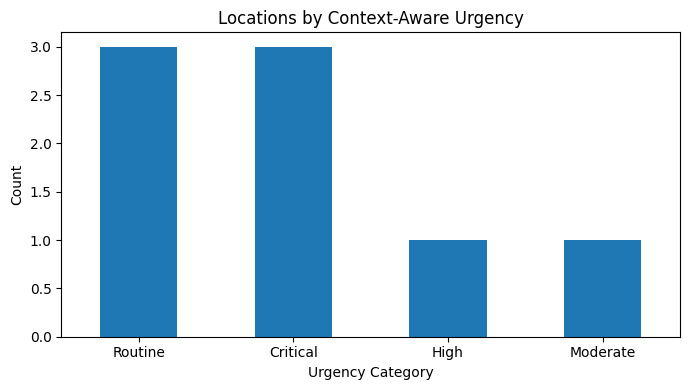

In [12]:

# Count by context urgency

urgency_counts = flood_geo_df["context_urgency"].value_counts()

fig, ax = plt.subplots(figsize=(7, 4))
urgency_counts.plot(kind="bar", ax=ax)
ax.set_title("Locations by Context-Aware Urgency")
ax.set_xlabel("Urgency Category")
ax.set_ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



## How This Relates to a Real Urban Digital Twin

In a full deployment, the same logic could be connected to:
- traffic camera feeds
- live weather updates
- road network layers
- sensor observations
- building and infrastructure models
- dashboard or 3D city interfaces
- alerting and workflow management systems

This course notebook simplifies those ideas into a portable Python workflow.



## Suggested Deployment Interpretation

A city operations team could use a digital twin workflow like this to:
1. monitor current flood severity points on a map
2. identify infrastructure-adjacent risk
3. track which locations worsen over time
4. update passability and access constraints
5. coordinate emergency response based on both severity and context



## Mini Exercise

Answer the following in your own words:

1. Why is digital twin integration more useful than viewing flood predictions as isolated records?
2. Why does infrastructure proximity matter when interpreting flood severity?
3. Why are temporal updates important in an urban disaster monitoring system?

Write your responses below.


In [13]:

# Write your Week 9 mini exercise responses here

# 1.
# 2.
# 3.



## Weekly Assignment

Choose one of the following:

### Option A
Write a short explanation of how this notebook represents a simplified digital twin workflow.  
Include:
- spatial layers
- infrastructure context
- temporal updates
- passability or urgency interpretation

### Option B
Modify the notebook by:
- adding 3 more flood locations
- adding 1 more critical site
- recomputing nearest-site distance and urgency categories

Then explain how the changes affected the digital twin interpretation.


In [14]:

# Week 9 assignment response area

digital_twin_summary = ""
modified_context_notes = ""

print("Digital Twin Summary:", digital_twin_summary)
print("Modified Context Notes:", modified_context_notes)


Digital Twin Summary: 
Modified Context Notes: 



## Key Takeaway

The main lesson from Week 9 is:

> **Urban digital twins add value by placing AI outputs inside a changing city context.**

Flood predictions become much more useful when they are linked to location, infrastructure, temporal updates, and operational meaning. That is what allows GeoAI to support real urban disaster intelligence.



## Suggested Extensions

Later versions of this notebook can be expanded with:
- real basemaps and GIS layers
- road-network routing impact
- dashboard integration
- Cesium or 3D city model linkage
- live weather or traffic updates
- sensor fusion with camera and infrastructure data

This keeps the notebook accessible while providing a strong bridge to more advanced digital twin platforms.
